## **Importação das bibliotecas e dados (AEP e Duas Unas)**

In [126]:
# %pip install ipykernel --break-system-packages
# %pip install scikit-learn --break-system-packages
# %pip install matplotlib --break-system-packages
# %pip install keras --break-system-packages
# %pip install tensorflow --break-system-packages
# %pip install pandas --break-system-packages
# %pip install plotly --break-system-packages
# %pip install seaborn --break-system-packages
# %pip install nbformat --break-system-packages
# %pip install keras --break-system-packages
# %pip install pswarm
#!pip install statsmodels


In [127]:
import statsmodels.api as sm
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.initializers import GlorotUniform    #Inicializador de pesos
from sklearn.model_selection import KFold
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from keras.activations import relu
from keras.initializers import GlorotUniform
from keras.initializers import GlorotNormal
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf #Biblioteca para machine learning

In [128]:

base_path = './dataset/'

scaler = MinMaxScaler(feature_range=(0, 1))  # Padronização dos dados

# carregando arquivo CSV
time_base = 'days'  # Escolha do tipo de agrupamento
duas_unas_dataset = f'{base_path}duas_unas/{time_base}/grouped_3_{time_base}.csv'  # Definição do caminho do diretório do dataset

validation_interval = 31 # Definição da parcela dos dados que serão retiradas do treinamento/teste para validação
time_step = 1  # Number of previous time steps to consider
output_steps = 30  # Number of future steps to predict

# transformando CSV em DataFrame
duas_unas_df = pd.read_csv(duas_unas_dataset)  # Transformação em dataset

indices_to_validate = duas_unas_df.index[-validation_interval:].tolist()  # Obtenção dos índices dos dadoss de validação

duas_unas_df['timestamp'] = pd.to_datetime(duas_unas_df['timestamp'])
# Ordenando o DataFrame pela coluna 'timestamp'
duas_unas_df = duas_unas_df.sort_values(by='timestamp')
duas_unas_arima = pd.DataFrame(duas_unas_df.drop((indices_to_validate[1:])).reset_index(drop=True))
duas_unas_df.set_index('timestamp', inplace=True)
# print(duas_unas_df)
#duas_unas_validation['timestamp'] = pd.to_datetime(duas_unas_validation['timestamp'])  # Idem da ação da linha de cima.


#duas_unas_df['index'] = range(len(duas_unas_df))  # Criação da coluna 'index' em que os valores vão de zero ao tamanho total do daframe
#duas_unas_validation['index'] = indices_to_validate  # Idem da acima da linha acima
#print(indices_to_validate)
#duas_unas_df['kwh'] = duas_unas_df['kWh fornecido']  # Criação da coluna 'kwh' que copia os dados da coluna 'kWh fornecido'
#duas_unas_validation['kwh'] = duas_unas_validation['kWh fornecido']  # Idem da acima da linha acima

#duas_unas_df.drop(columns=['timestamp'], inplace=True)  # Remoção da coluna 'timestamp', inclusive no dataframe original
#duas_unas_validation.drop(columns=['timestamp'], inplace=True)  # Idem da acima da linha acima

#duas_unas_df.drop(columns=['kWh fornecido'], inplace=True)  # Remoção da coluna 'kWh fornecido', inclusive no dataframe original
#duas_unas_validation.drop(columns=['kWh fornecido'], inplace=True)  # Idem da acima da linha acima

#duas_unas_df.drop(columns=['index'], inplace=True)  # Remoção da coluna 'kWh fornecido', inclusive no dataframe original
duas_unas_df_scaled = scaler.fit_transform(duas_unas_df)
duas_unas_df_scaled = pd.DataFrame(duas_unas_df_scaled)
duas_unas_arima['kWh fornecido'] = duas_unas_df_scaled[:(len(duas_unas_df_scaled)-output_steps)]
duas_unas_validation_scaled = duas_unas_df_scaled.tail(validation_interval)  # Criação do dataset de validação
duas_unas_df_scaled = duas_unas_df_scaled.drop(indices_to_validate).reset_index(drop=True)  # Retirada dos dados de validação do dataset original de treino/teste


print(duas_unas_arima)
print(len(duas_unas_arima))
# X = duas_unas_df['index'].values.reshape(-1,1)  # Cria o array X com os índices do dataframe duas_unas_df
# y = duas_unas_df['kwh'].values  # Cria o array y com os dados de energia de duas_unas_df
# #print(y)
# X_validation = duas_unas_validation['index'].values.reshape(-1,1)  # Cria o array X_validation com os índices do dataframe duas_unas_validation
# y_validation = duas_unas_validation['kwh'].values  # Cria o array y com os dados de energia de duas_unas_validation
# #print(X_validation)

    timestamp  kWh fornecido
0  2023-10-01       0.000000
1  2023-10-04       0.345662
2  2023-10-07       0.747771
3  2023-10-10       0.914409
4  2023-10-13       0.913913
..        ...            ...
69 2024-04-25       0.903549
70 2024-04-28       0.896600
71 2024-05-01       0.839799
72 2024-05-04       0.878018
73 2024-05-07       0.817071

[74 rows x 2 columns]
74


In [129]:
import tensorflow as tf

def identify_peaks_and_valleys(y_test):
    # Converte y_test em um tensor
    #y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    # Inicializa pesos como um tensor de 1s do mesmo formato
    weights = tf.ones(tf.shape(y_test), dtype=tf.float32)

    # Condicional para verificar se y_test tem pelo menos 3 elementos
    mask = tf.size(y_test) < 3

    # Função para processar picos e vales
    def process_peaks_and_valleys():
        # Certifique-se de que y_test é do tipo float32
        y_test_float = tf.cast(y_test, tf.float32)

        # Obtém os índices de picos e vales para elementos intermediários
        # Corrigido: use tf.expand_dims para garantir que o primeiro elemento tenha o formato correto
        y_test_prev = tf.concat([tf.expand_dims(y_test_float[0], axis=0), y_test_float[:-1]], axis=0)  # Adiciona o primeiro elemento como anterior
        y_test_next = tf.concat([y_test_float[1:], tf.expand_dims(y_test_float[-1], axis=0)], axis=0)  # Adiciona o último elemento como próximo

        # Define picos e vales para os elementos intermediários
        peaks = tf.where((y_test_float > y_test_prev) & (y_test_float > y_test_next))
        valleys = tf.where((y_test_float < y_test_prev) & (y_test_float < y_test_next))

        # Atualiza os pesos para picos e vales intermediários
        weights_updated = tf.tensor_scatter_nd_update(weights, peaks, tf.fill(tf.shape(peaks)[:1], 3.0))
        weights_updated = tf.tensor_scatter_nd_update(weights_updated, valleys, tf.fill(tf.shape(valleys)[:1], 3.0))

    #     # Verificação para o primeiro elemento
    #     first_idx = 0
    #     first_elem = tf.gather(y_test, first_idx)
    #     second_elem = tf.gather(y_test, first_idx + 1)
    #     third_elem = tf.gather(y_test, first_idx + 2)

    #     # Atualiza o peso do primeiro elemento
    #     first_weight_update = tf.where(
    #         (first_elem < second_elem) & (first_elem < third_elem) |
    #         (first_elem > second_elem) & (first_elem > third_elem),
    #         3.0,
    #         weights_updated[first_idx]
    #     )
    #     weights_updated = tf.tensor_scatter_nd_update(weights_updated, [[first_idx]], [first_weight_update])


    #     # Verificação para o último elemento
    #     last_idx = tf.shape(y_test)[0] - 1
    #     last_elem = tf.gather(y_test, last_idx)
    #     second_last_elem = tf.gather(y_test, last_idx - 1)
    #     third_last_elem = tf.gather(y_test, last_idx - 2)

    # # Atualiza o peso do último elemento
    #     last_weight_update = tf.where(
    #         (last_elem < second_last_elem) & (last_elem < third_last_elem) |
    #         (last_elem > second_last_elem) & (last_elem > third_last_elem),
    #         3.0,
    #         weights_updated[last_idx]
    #     )
    #     weights_updated = tf.tensor_scatter_nd_update(weights_updated, [[last_idx]], [last_weight_update])

        return weights_updated

    # Condicional para executar a função de processamento se y_test tiver 3 ou mais elementos
    weights = tf.cond(mask, lambda: weights, process_peaks_and_valleys)

    return weights


In [130]:
# Função WMAE ajustada com pesos para picos e vales
def wmae(y_test, y_pred):
    # Convertendo y_test e y_pred para float32
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    #y_test = tf.squeeze(y_test)
    #y_pred = tf.squeeze(y_pred)

    weights = identify_peaks_and_valleys(y_test)

    return (tf.reduce_sum(weights * tf.abs(y_test - y_pred)) / tf.reduce_sum(weights))

In [131]:
def create_dataset(data, time_step, output_steps):  # Função para construção do dataset
    X= []  # Criação das listas
    y = []
    for i in range(len(data) - time_step - output_steps + 1):  # Loop
        X.append(data.iloc[i:(i + time_step), 0])  # Construção do dataset com `.iloc`
        y.append(data.iloc[(i + time_step):(i + time_step + output_steps), 0])
    return np.array(X), np.array(y)


In [132]:
def avaliacao_multistep(janela_real, janela_prevista):

    if len(janela_real) != len(janela_prevista):
        raise ValueError("As janelas reais e previstas devem ter o mesmo comprimento.")
    
    janela_real = np.array(janela_real)
    janela_prevista = np.array(janela_prevista)

    print(janela_real[0])
    
    mae_med = 0
    mse_med = 0
    rmse_med = 0
    mape_med = 0
    acuracia_med = 0
    # Converte as listas para arrays NumPy
    #janela_real = np.array(janela_real)
    #janela_prevista = np.array(janela_prevista)

    mae = round(mean_absolute_error(janela_real, janela_prevista), 3) # Arredondamento com três casas decimais
    print("MAE(Erro absoluto médio) Score of LSTM model = ",mae)
    print(" ")

    mse = round(mean_squared_error(janela_real, janela_prevista), 3)
    print("MSE(Erro quadrático médio) Score of LSTM model = ",mse)
    print(" ")
            
    rmse = round(np.sqrt(mse), 3)
    print("RMSE(Raiz do erro quadrático médio) Score of LSTM model = ",rmse)
    print(" ")

    mape = round(mean_absolute_percentage_error(janela_real, janela_prevista), 2)
    print("MAPE(Erro percentual médio absoluto) Score of LSTM model = ",mape)
    print(" ")
            
    ### Cálculo da ACURÁCIA ###
            
    # Calcula a diferença percentual
    diferencas_percentuais = np.abs((janela_real - janela_prevista) / janela_real)
    # print(f"dif_perc",diferencas_percentuais)
    # print("len(janela_real)",len(janela_real))

    # Conta quantas diferenças percentuais estão dentro da tolerância
    acertos = np.sum(diferencas_percentuais <= 0.05) #0.05 é a tolerância

    # Calcula a acurácia
    acuracia = acertos / len(janela_real)   
    acuracia = round(100 * acuracia, 2)
            
    print("Accuracy Score of LSTM model = ",acuracia)
    
    # mae_med += mae
    # mse_med += mse
    # rmse_med += rmse
    # mape_med += mape
    # acuracia_med += acuracia
            
    # mae_med = mae_med/(len(janela_prevista))
    # mse_med /=(len(janela_prevista))
    # rmse_med /=(len(janela_prevista))
    # mape_med /=(len(janela_prevista))
    # acuracia_med /=(len(janela_prevista))
    
    return round(mae,2), round(mse,2), round(rmse,2), round(mape,2), round(acuracia,2)

In [133]:
#scaled_kwh = scaler.fit_transform(duas_unas_df['kwh'].values.reshape(-1, 1))  # padronização de duas_unas_df
#print(len(scaled_kwh))
#scaled_kwh_validation = scaler.fit_transform(duas_unas_validation['kwh'].values.reshape(-1,1))  # padronização de duas_unas_validacao

# Create the dataset
X, y = create_dataset(duas_unas_df_scaled, time_step, output_steps)
X_validation, y_validation = create_dataset(duas_unas_validation_scaled, time_step, output_steps)
# print(f"X_validation", X_validation)
# print(f"y_validation", y_validation[0])
# Reshape input to be [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)
X_validation = X_validation.reshape(X_validation.shape[0], X_validation.shape[1], 1)
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print(X_train.shape)
# print(y_train.shape)

# print(f"X_test", X_test)
# print(f"y_test", y_test)

In [134]:
def main_looping(output_steps, X_train, y_train, X_validation, y_validation):


    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(44, return_sequences=True, input_shape=(X_train.shape[1], 1),
                        kernel_initializer=GlorotUniform(),     # Inicializa os pesos
                        recurrent_initializer=GlorotUniform(),  # Inicializa os pesos recorrentes
                        bias_initializer=GlorotUniform()))       # Inicializa os bias
    model.add(Dropout(0.39))
    model.add(LSTM(44, return_sequences=True,
                        kernel_initializer=GlorotUniform(),     # Inicializa os pesos
                        recurrent_initializer=GlorotUniform(),  # Inicializa os pesos recorrentes
                        bias_initializer=GlorotUniform()))       # Inicializa os bias
    model.add(Dropout(0.39))
    model.add(LSTM(44, return_sequences=False,
                        kernel_initializer=GlorotUniform(),     # Inicializa os pesos
                        recurrent_initializer=GlorotUniform(),  # Inicializa os pesos recorrentes
                        bias_initializer=GlorotUniform()))       # Inicializa os bias
    model.add(Dropout(0.39))
    model.add(Dense(output_steps, activation="relu",kernel_initializer=GlorotUniform()))

    learning_rate = 0.005
    optimizer = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss=wmae)

    early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=6, restore_best_weights=True)
    #callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0.02, patience=2, verbose=0, mode='auto')
    history = model.fit(X_train, y_train, epochs=10000, batch_size=15, validation_data=(X_test, y_test), callbacks=[early_stopping])
    # Train the model
    #history = model.fit(X_train, y_train, epochs=1000, batch_size=4, verbose=1, callbacks=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, verbose=1))

    # Plotar as perdas de treinamento e validação
    plt.plot(history.history['loss'], label='Loss de Treinamento')
    plt.plot(history.history['val_loss'], label='Loss de Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()
    plt.show()

    return model

c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 429ms/step - loss: 0.8585 - val_loss: 0.7996
Epoch 2/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.7943 - val_loss: 0.7141
Epoch 3/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.6931 - val_loss: 0.5750
Epoch 4/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.5496 - val_loss: 0.3530
Epoch 5/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3271 - val_loss: 0.1266
Epoch 6/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1801 - val_loss: 0.0833
Epoch 7/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1683 - val_loss: 0.1205
Epoch 8/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1562 - val_loss: 0.1604
Epoch 9/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1689 - val_loss: 0.1446
Epoch 10/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1634 - val_loss: 0.0551
Epoch 11/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1458 - val_loss: 0.0462
Epoch 12/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/st

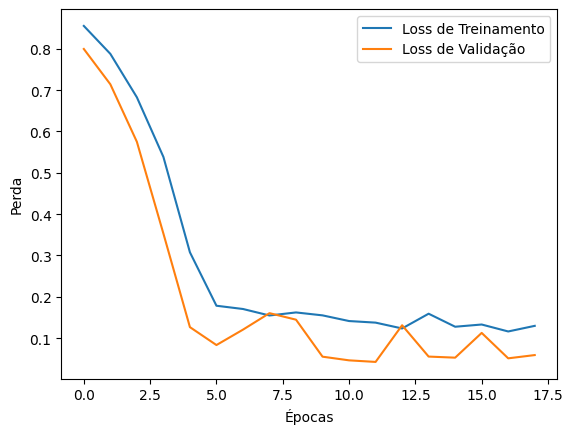

In [135]:
model = main_looping(output_steps, X_train, y_train, X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step


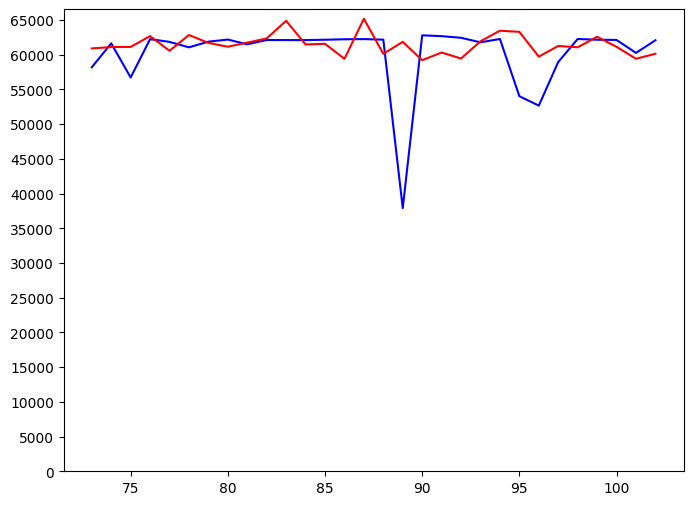

In [136]:
y_pred_lstm = model.predict(X_test)
y_pred_lstm_rescaled = scaler.inverse_transform(y_pred_lstm)

y_test_reshaped = y_test[0].reshape(-1, 1)
y_test_rescaled = scaler.inverse_transform(y_test_reshaped)

y_pred_lstm_rescaled = np.array(y_pred_lstm_rescaled)
y_pred_lstm_reshaped = y_pred_lstm_rescaled[0].reshape(-1, 1)

# print(y_test_rescaled.shape)
# print(indices_to_validate[0:output_steps])

# print(y_test_rescaled)
# print(y_pred_reshaped)

# means = np.mean(y_pred_rescaled)
# stds = np.std(y_test_rescaled[0]) 
# print(means) 

plt.figure(figsize=(8,6))
plt.plot(indices_to_validate[0:output_steps], y_test_rescaled, label="Original", color='blue')
plt.plot(indices_to_validate[0:output_steps], y_pred_lstm_reshaped, label="Predição", color='red')
#plt.fill_between(indices_to_validate, means - stds, means + stds, color='gray', alpha=0.3, label=f'±1 Desvio Padrão ({stds:.2f})')
#plt.plot([indices_to_validate[0],indices_to_validate[12]], [means, means], color='yellow', linestyle='--', label=f'Média ({means:.2f})')
plt.yticks(np.arange(0,70000,step=5000))
plt.show()

In [137]:
    
forecast_arima = []
for i in range(1,len(X_test)+1): #X_train_reshaped = X_train.reshape(32, -1)  # Remover dimensões extras
    df = pd.DataFrame(duas_unas_arima[:(len(X_train)+i)])

    #df = pd.DataFrame(X_train)
    #print(df)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)

    # 2. Ajustar o modelo ARIMA
    model_a = ARIMA(df['kWh fornecido'], order=(2,0,2))
    model_fit = model_a.fit()

    # 3. Prever múltiplos passos à frente
    forecast = model_fit.forecast(steps=30)
    #print(type(forecast))
    forecast_arima.append(forecast.values)
#forecast_arima = pd.DataFrame(forecast_arima)
print(forecast_arima)

c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\rena

[array([0.91831235, 0.88056001, 0.85743413, 0.83469563, 0.81807861,
       0.80354009, 0.79216448, 0.78263334, 0.77497807, 0.76866768,
       0.76354854, 0.75935464, 0.75593954, 0.75314822, 0.75087198,
       0.74901314, 0.74749649, 0.74625837, 0.74524796, 0.74442322,
       0.74375011, 0.74320071, 0.7427523 , 0.74238632, 0.74208761,
       0.7418438 , 0.74164482, 0.7414824 , 0.74134985, 0.74124165]), array([0.85671577, 0.83066687, 0.81566108, 0.80031789, 0.78938727,
       0.77969661, 0.77219842, 0.76589221, 0.76085522, 0.75670225,
       0.7533446 , 0.750597  , 0.74836529, 0.74654426, 0.74506254,
       0.7438548 , 0.74287144, 0.74207024, 0.74141773, 0.74088617,
       0.74045322, 0.74010055, 0.73981328, 0.73957929, 0.73938869,
       0.73923344, 0.73910697, 0.73900397, 0.73892006, 0.73885171]), array([0.91547115, 0.91125446, 0.86831315, 0.85314076, 0.83059225,
       0.81725214, 0.80373222, 0.79397431, 0.78531789, 0.77856571,
       0.77286555, 0.76828384, 0.764488  , 0.76140159, 0.

c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [138]:
print(y_pred_lstm)
print(forecast_arima)

[[0.88333946 0.88624597 0.88655096 0.9090199  0.8784091  0.91140336
  0.8948977  0.886922   0.8954776  0.9042294  0.9410814  0.8916639
  0.8930142  0.86163723 0.94538516 0.8721206  0.89712304 0.8587871
  0.8748289  0.862303   0.8982681  0.9204076  0.9180007  0.8662332
  0.8884715  0.8857818  0.90769285 0.88668466 0.86183107 0.8722415 ]
 [0.8873963  0.8904519  0.89075655 0.9135538  0.8828454  0.9157184
  0.89914787 0.89107025 0.8995728  0.90864193 0.9454901  0.8957794
  0.89756346 0.8656442  0.9499321  0.87634957 0.9012562  0.86309963
  0.87915546 0.86647797 0.90272343 0.9247777  0.92236495 0.8702215
  0.89272004 0.89017004 0.91194713 0.8906719  0.86593556 0.8765286 ]
 [0.8913808  0.89458215 0.89488554 0.9180065  0.8872     0.91995716
  0.90332234 0.8951435  0.9035944  0.91297483 0.9498192  0.8998193
  0.9020296  0.8695811  0.95439684 0.8805012  0.90531594 0.86733395
  0.8834044  0.87057674 0.9070971  0.9290698  0.9266483  0.8741365
  0.8968922  0.89447874 0.916123   0.89458805 0.869967

In [139]:
concat_preds = []
for i in range(len(forecast_arima)):    
    pred_lstm_to_concat = y_pred_lstm[i]
    pred_arima_to_concat = forecast_arima[i]
    # pred_lstm_values = pred_lstm_to_concat.values
    # pred_arima_values = pred_arima_to_concat.values

    conc = np.concatenate((pred_arima_to_concat,pred_lstm_to_concat), axis=0)
    # print(pred_arima_to_concat)
    # print(pred_lstm_to_concat)
    # print(conc)
    concat_preds.append(conc)
#print(concat_preds)

print(len(concat_preds[0]))

    

60


In [140]:
# Certifique-se de que seu array tenha o formato correto
concat_preds_array = np.array(concat_preds)
data = concat_preds_array.flatten()  # Transforma o array 2D em 1D
num_sequences = 9
sequence_length = 60

# Verifica se o tamanho total do array é compatível com o número de sequências e o comprimento das sequências
if len(data) < num_sequences * sequence_length:
    raise ValueError("O array não possui dados suficientes para criar as sequências.")

# Cria as sequências
sequences = np.array([data[i * sequence_length:(i + 1) * sequence_length] for i in range(num_sequences)])

print(sequences.shape)  # Isso deve imprimir (11, 60)
print(sequences)  # Imprime as sequências criadas


(9, 60)
[[0.91831235 0.88056001 0.85743413 0.83469563 0.81807861 0.80354009
  0.79216448 0.78263334 0.77497807 0.76866768 0.76354854 0.75935464
  0.75593954 0.75314822 0.75087198 0.74901314 0.74749649 0.74625837
  0.74524796 0.74442322 0.74375011 0.74320071 0.7427523  0.74238632
  0.74208761 0.7418438  0.74164482 0.7414824  0.74134985 0.74124165
  0.88333946 0.88624597 0.88655096 0.90901989 0.87840909 0.91140336
  0.8948977  0.886922   0.89547759 0.9042294  0.9410814  0.89166391
  0.89301419 0.86163723 0.94538516 0.87212062 0.89712304 0.85878712
  0.87482888 0.86230302 0.8982681  0.92040759 0.9180007  0.86623323
  0.88847148 0.88578182 0.90769285 0.88668466 0.86183107 0.8722415 ]
 [0.85671577 0.83066687 0.81566108 0.80031789 0.78938727 0.77969661
  0.77219842 0.76589221 0.76085522 0.75670225 0.7533446  0.750597
  0.74836529 0.74654426 0.74506254 0.7438548  0.74287144 0.74207024
  0.74141773 0.74088617 0.74045322 0.74010055 0.73981328 0.73957929
  0.73938869 0.73923344 0.73910697 0.7390

In [141]:
#sequences_rescaled = scaler.fit_transform(sequences)
#sequences_rescaled

In [142]:
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(sequences, y_test, test_size=0.2, random_state=42)

c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.7127 - val_loss: 0.5566
Epoch 2/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.5353 - val_loss: 0.4122
Epoch 3/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3989 - val_loss: 0.3019
Epoch 4/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.2857 - val_loss: 0.2192
Epoch 5/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.2082 - val_loss: 0.1548
Epoch 6/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1496 - val_loss: 0.1044
Epoch 7/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1014 - val_loss: 0.0663
Epoch 8/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0621 - val_loss: 0.0388
Epoch 9/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0376 - val_loss: 0.0215
Epoch 10/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0223 - val_loss: 0.0129
Epoch 11/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0135 - val_loss: 0.0103
Epoch 12/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/ste

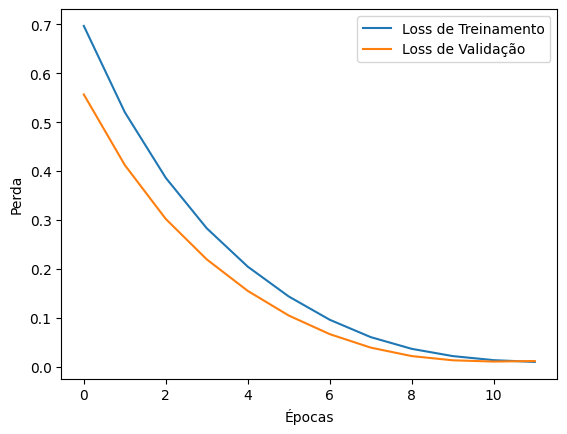

In [143]:
from keras.models import Sequential
from keras.layers import Dense

# Definindo o tamanho da entrada e da saída
input_shape = 60  # Tamanho da sequência de entrada
output_shape = 30  # Tamanho da janela de previsão de saída

# Criando o modelo
model2 = Sequential()
model2.add(Dense(128, input_dim=input_shape, activation='relu'))  # Camada oculta 1
model2.add(Dense(64, activation='relu'))                          # Camada oculta 2
model2.add(Dense(output_shape, activation='linear'))              # Camada de saída (para regressão)

# Compilando o modelo
model2.compile(loss='mean_squared_error', optimizer='adam')

early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=1, restore_best_weights=True)

# Treinando o modelo
history = model2.fit(X_train_mlp, y_train_mlp, epochs=10000, batch_size=3, validation_data=(X_test_mlp, y_test_mlp), callbacks=[early_stopping])

# Plotar as perdas de treinamento e validação
plt.plot(history.history['loss'], label='Loss de Treinamento')
plt.plot(history.history['val_loss'], label='Loss de Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()


In [144]:
pred_val_lstm = model.predict(X_validation)

#print("pred_val_lstm", pred_val_lstm[0])

df = pd.DataFrame(duas_unas_arima)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# 2. Ajustar o modelo ARIMA
model_a = ARIMA(df['kWh fornecido'], order=(2,0,2))
model_fit = model_a.fit()

# 3. Prever múltiplos passos à frente
pred_val_arima = model_fit.forecast(steps=30)

X_val_concat = np.concatenate((pred_val_lstm[0],pred_val_arima), axis=0)
X_val_concat_array = np.array(X_val_concat)
X_val_concat = np.array(X_val_concat).reshape(1, -1)  # shape será (1, 60)
# print("X_val_concat_len", len(X_val_concat))

# print("X_val_concat", X_val_concat)

y_pred_mlp = model2.predict(X_val_concat)

y_validation_rescaled = scaler.inverse_transform(y_validation)
y_pred_mlp_rescaled = scaler.inverse_transform(y_pred_mlp)

# Ajustando y_pred_mlp_rescaled para ser 1D - ravel() transforma o array 2D em um array 1D, removendo a dimensão extra desnecessária
y_validation_rescaled = y_validation_rescaled.reshape(-1)
y_pred_mlp_rescaled = y_pred_mlp_rescaled.reshape(-1)



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step


c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)
c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 3D will be used.
  self._init_dates(dates, freq)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


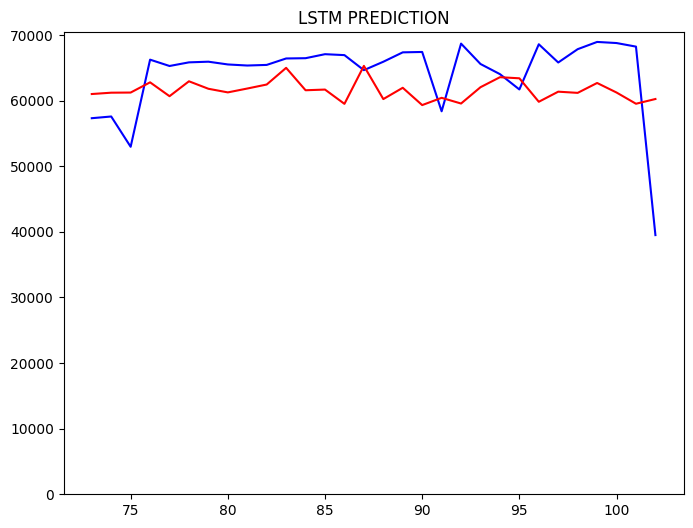

In [145]:
pred_val_lstm_rescaled = scaler.inverse_transform(pred_val_lstm)
pred_val_lstm_rescaled = pred_val_lstm_rescaled.reshape(-1)

plt.figure(figsize=(8,6))
plt.plot(indices_to_validate[0:output_steps], y_validation_rescaled, label="Original", color='blue')
plt.plot(indices_to_validate[0:output_steps], pred_val_lstm_rescaled, label="Predição", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("LSTM PREDICTION")
plt.show()

In [146]:
avaliacao_multistep(y_validation_rescaled, pred_val_lstm_rescaled)

57325.32
MAE(Erro absoluto médio) Score of LSTM model =  5346.923
 
MSE(Erro quadrático médio) Score of LSTM model =  42570074.723
 
RMSE(Raiz do erro quadrático médio) Score of LSTM model =  6524.575
 
MAPE(Erro percentual médio absoluto) Score of LSTM model =  0.09
 
Accuracy Score of LSTM model =  23.33


(5346.92, 42570074.72, 6524.58, 0.09, 23.33)

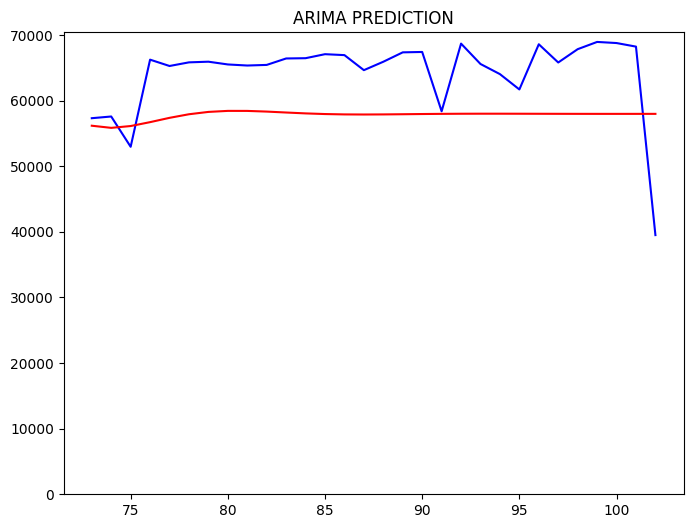

In [147]:
pred_val_arima_reshaped = pred_val_arima.values.reshape(-1, 1)
pred_val_arima_rescaled = scaler.inverse_transform(pred_val_arima_reshaped)
pred_val_arima_rescaled = pred_val_arima_rescaled.reshape(-1)

plt.figure(figsize=(8,6))
plt.plot(indices_to_validate[0:output_steps], y_validation_rescaled, label="Original", color='blue')
plt.plot(indices_to_validate[0:output_steps], pred_val_arima_rescaled, label="Predição", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("ARIMA PREDICTION")
plt.show()

In [148]:
avaliacao_multistep(y_validation_rescaled, pred_val_arima_rescaled)

57325.32
MAE(Erro absoluto médio) Score of LSTM model =  7859.965
 
MSE(Erro quadrático médio) Score of LSTM model =  73513891.023
 
RMSE(Raiz do erro quadrático médio) Score of LSTM model =  8574.024
 
MAPE(Erro percentual médio absoluto) Score of LSTM model =  0.12
 
Accuracy Score of LSTM model =  10.0


(7859.96, 73513891.02, 8574.02, 0.12, 10.0)

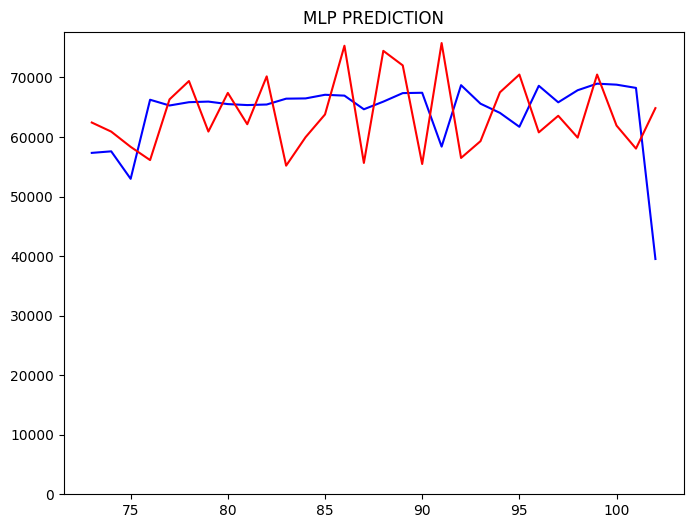

In [149]:
plt.figure(figsize=(8,6))
plt.plot(indices_to_validate[0:output_steps], y_validation_rescaled, label="Original", color='blue')
plt.plot(indices_to_validate[0:output_steps], y_pred_mlp_rescaled, label="Predição", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("MLP PREDICTION")
plt.show()

In [150]:
avaliacao_multistep(y_validation_rescaled, y_pred_mlp_rescaled)

57325.32
MAE(Erro absoluto médio) Score of LSTM model =  7234.123
 
MSE(Erro quadrático médio) Score of LSTM model =  77239430.445
 
RMSE(Raiz do erro quadrático médio) Score of LSTM model =  8788.597
 
MAPE(Erro percentual médio absoluto) Score of LSTM model =  0.12
 
Accuracy Score of LSTM model =  20.0


(7234.12, 77239430.44, 8788.6, 0.12, 20.0)

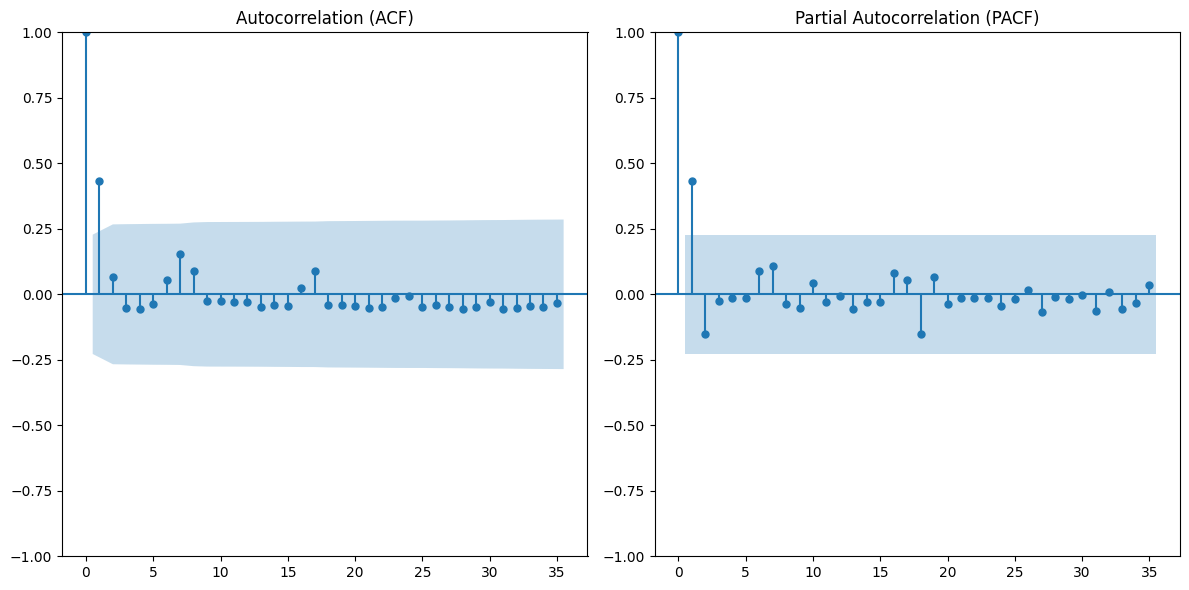

(-9.934915914005328, 2.7599566736862606e-17, 0, 73, {'1%': -3.5232835753964475, '5%': -2.902030597326081, '10%': -2.5883710883843123}, -172.92580403066842)


In [151]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Função para plotar ACF e PACF
def plot_acf_pacf(data, lags=35):
    """
    Plota os gráficos de ACF e PACF da série temporal.
    
    Parâmetros:
    - data: série temporal (pandas Series)
    - lags: número de lags a serem considerados nos gráficos (default = 20)
    """
    plt.figure(figsize=(12, 6))
    
    # Plot ACF
    plt.subplot(1, 2, 1)
    plot_acf(data, lags=lags, ax=plt.gca())
    plt.title("Autocorrelation (ACF)")
    
    # Plot PACF
    plt.subplot(1, 2, 2)
    plot_pacf(data, lags=lags, ax=plt.gca())
    plt.title("Partial Autocorrelation (PACF)")
    
    plt.tight_layout()
    plt.show()

    # TESTE DE ESTACIONARIEDADE - ADF
    print(adfuller(data, maxlag=None, regression='c', autolag='AIC', store=False, regresults=False))

# Chamando a função para plotar ACF e PACF
plot_acf_pacf(df['kWh fornecido'])